# Heart Disease Classification using $k$-NN

In this notebook, we implement and compare three approaches for $k$-Nearest Neighbors ($k$-NN) classification:
1. **Custom KNN (Scratch):** Built from scratch using pure NumPy ($L_2$ Euclidean distance).
2. **Sklearn Normal Baseline:** Standard Scikit-Learn `KNeighborsClassifier`.
3. **Sklearn Pipeline:** `Pipeline` with `GridSearchCV` hyperparameter tuning (optimized for **Recall**).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn modules
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## 1. Data Loading & Initial Inspection

In [2]:
# Load dataset
df = pd.read_csv('heart.csv')

print("Dataset Shape:", df.shape, "\n")
print("Missing Values:\n", df.isnull().sum(), "\n")
df.head()

Dataset Shape: (303, 14) 

Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64 



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 2. Exploratory Data Analysis (EDA)

We explore target class balance and key feature

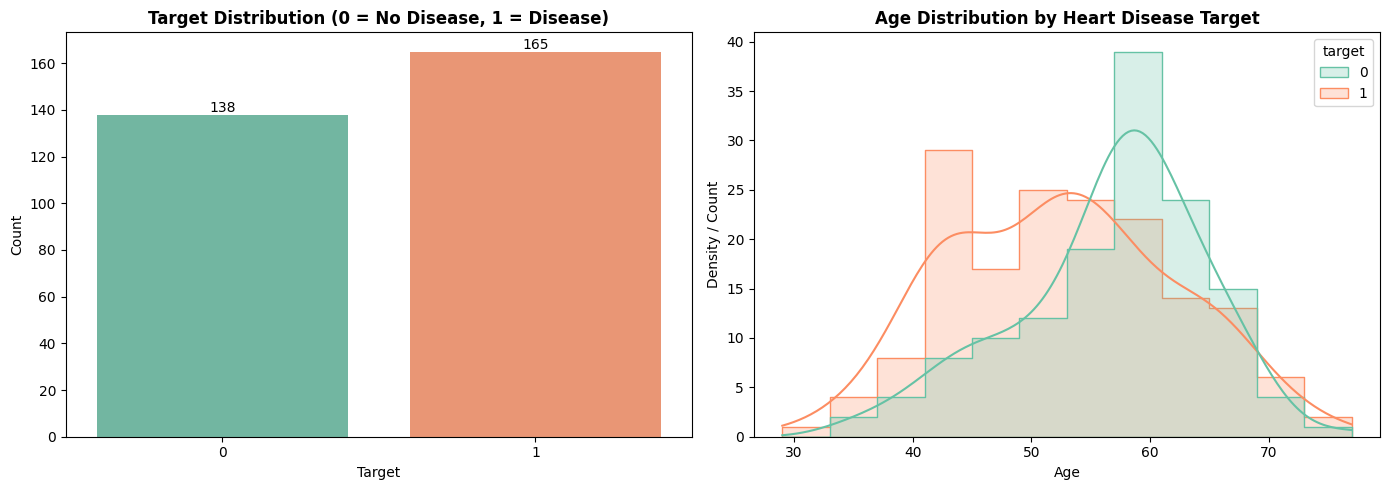

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target Class Proportion
sns.countplot(x='target', hue='target', data=df, palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Target Distribution (0 = No Disease, 1 = Disease)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Count')

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Age Distribution by Target Condition
sns.histplot(data=df, x='age', hue='target', kde=True, element='step', palette='Set2', ax=axes[1])
axes[1].set_title('Age Distribution by Heart Disease Target', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density / Count')

plt.tight_layout()

plt.show()

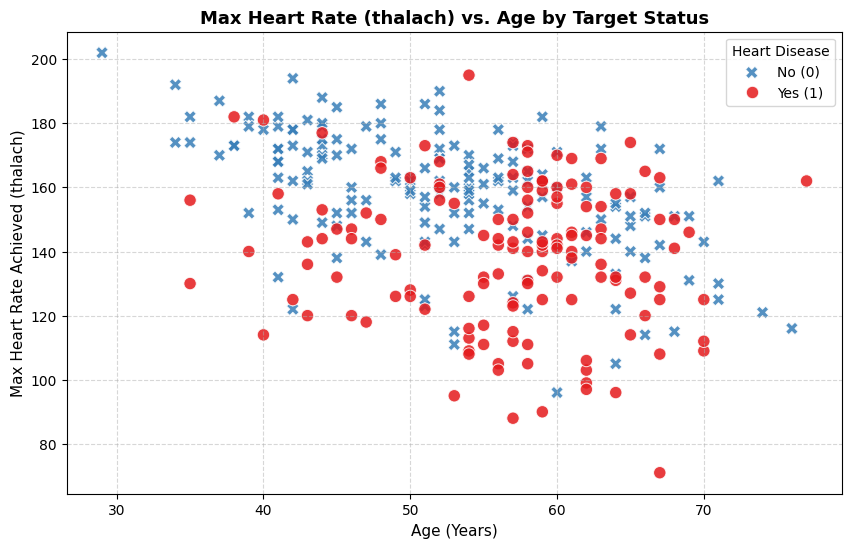

In [4]:
plt.figure(figsize=(10, 6))

# Scatter plot Max Heart Rate (thalach) vs. Age by Target Status
sns.scatterplot(data=df, x='age', y='thalach', hue='target', style='target', palette='Set1', s=80, alpha=0.85)
plt.title('Max Heart Rate (thalach) vs. Age by Target Status', fontsize=13, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=11)
plt.ylabel('Max Heart Rate Achieved (thalach)', fontsize=11)
plt.legend(title='Heart Disease', labels=['No (0)', 'Yes (1)'])
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

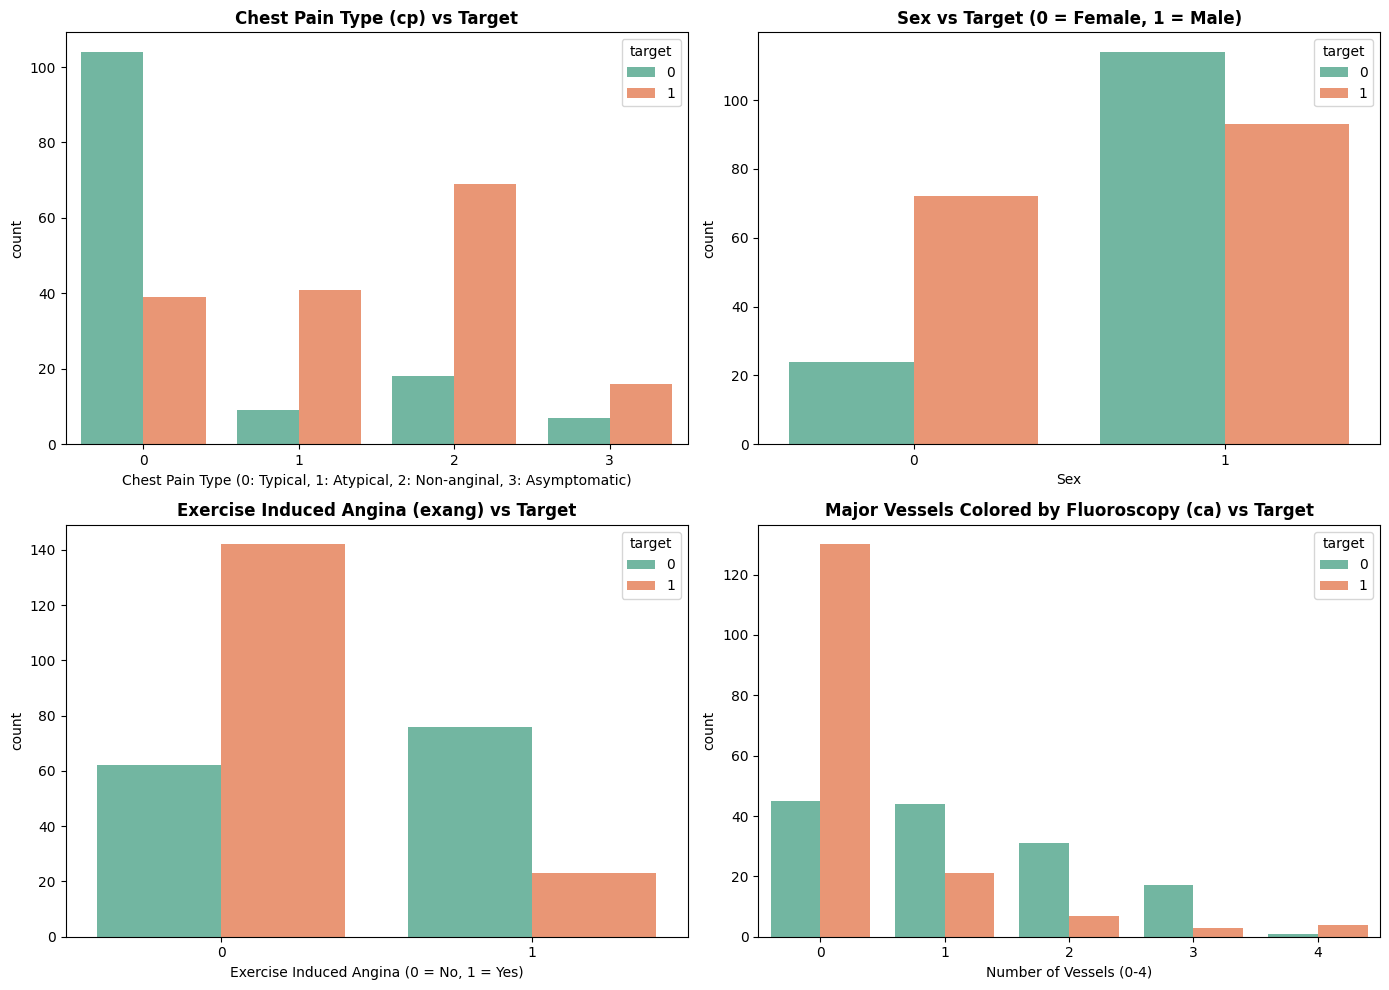

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chest Pain Type (cp) vs Target
sns.countplot(x='cp', hue='target', data=df, palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Chest Pain Type (cp) vs Target', fontweight='bold')
axes[0, 0].set_xlabel('Chest Pain Type (0: Typical, 1: Atypical, 2: Non-anginal, 3: Asymptomatic)')

# Sex vs Target
sns.countplot(x='sex', hue='target', data=df, palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Sex vs Target (0 = Female, 1 = Male)', fontweight='bold')
axes[0, 1].set_xlabel('Sex')

# Exercise Induced Angina (exang) vs Target
sns.countplot(x='exang', hue='target', data=df, palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Exercise Induced Angina (exang) vs Target', fontweight='bold')
axes[1, 0].set_xlabel('Exercise Induced Angina (0 = No, 1 = Yes)')

# Number of Major Vessels (ca) vs Target
sns.countplot(x='ca', hue='target', data=df, palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Major Vessels Colored by Fluoroscopy (ca) vs Target', fontweight='bold')
axes[1, 1].set_xlabel('Number of Vessels (0-4)')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Train-Test Split

Distance-based classifiers like $k$-NN require features to be on the same scale. We split the data into training and test sets ($80/20$) before fitting our scalar to prevent data leakage.

In [6]:
# Separate features (X) and target (y)
X = df.drop(columns=['target']).values
y = df['target'].values

# Train-Test Split (80% Train, 20% Test with Stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40, stratify=y
)

# Feature Scaling (Essential for KNN distance calculations!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape:  {X_test_scaled.shape}")

X_train shape: (242, 13)
X_test shape:  (61, 13)


## 4. Custom $k$-NN Classifier from Scratch

Below is a pure NumPy implementation of $k$-NN using $L_2$ Euclidean distance and standard majority class voting.

In [7]:
# KNN Implementation from Scratch - for binary classification

class KNNClassifierFromScratch:
    def __init__(self, k):
        self.k = k

    def _euclidean_dist(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        self.classes_ = np.unique(y)
        return self

    def _predict_one(self, x):
        distances = [self._euclidean_dist(x, x_train) for x_train in self.X_train]
        knn_indices = np.argsort(distances)[:self.k]
        knn_classes = [self.y_train[i] for i in knn_indices]
        majority_classes = np.argmax(np.bincount(knn_classes))
        return majority_classes

    def predict(self, X):
        X = np.array(X)
        y_pred = [self. _predict_one(x) for x in X]
        return np.array(y_pred)
        
        
        

## 5. Hyperparameter Tuning via GridSearchCV

In medical diagnostics, **Recall (Sensitivity)** is prioritized to minimize False Negatives (un-diagnosed heart disease cases). We search across $k \in [1, 20]$ using 5-fold cross-validation.

In [8]:
# Define Pipeline with Scaler and KNN Classifier

steps = [('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]
pipeline = Pipeline(steps)

# Define Hyperparameter Search Space for k
param_grid = {'knn__n_neighbors': list(range(1, 21, 2))}

# Setup GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='recall'
)

# Fit GridSearchCV on RAW X_train
grid_search.fit(X_train, y_train)

# Best Parameters and Best Score
print("Best Parameters Found:", grid_search.best_params_)
print(f"Best 5-Fold Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

Best Parameters Found: {'knn__n_neighbors': 15}
Best 5-Fold Cross-Validation Accuracy: 0.9319


## 6. Model Training & Evaluation Comparison

We train all three models with the optimal $k$ value ($k=15$) and evaluate their predictions on the test set.

In [9]:
# xtract best k value dynamically from Grid Search
best_k = grid_search.best_params_['knn__n_neighbors']

# Custom KNN from Scratch
scratch_knn = KNNClassifierFromScratch(k=best_k)
scratch_knn.fit(X_train_scaled, y_train)
y_pred_scratch = scratch_knn.predict(X_test_scaled)

# Normal Sklearn KNN Baseline
knn_normal = KNeighborsClassifier(n_neighbors=best_k)
knn_normal.fit(X_train_scaled, y_train)
y_pred_normal = knn_normal.predict(X_test_scaled)

# Sklearn Pipeline + GridSearchCV
y_pred_pipeline = grid_search.best_estimator_.predict(X_test)


# Metric Evaluation Function
def evaluate_predictions(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ]

# Compute metrics
m_scratch  = evaluate_predictions(y_test, y_pred_scratch)
m_normal   = evaluate_predictions(y_test, y_pred_normal)
m_pipeline = evaluate_predictions(y_test, y_pred_pipeline)

# Build Comparison Table
df_results = pd.DataFrame({
    "Approach": [
        f"1. KNN Scratch (Custom NumPy, k={best_k})",
        f"2. KNN Normal (Sklearn Baseline, k={best_k})",
        f"3. KNN Pipeline (GridSearchCV Tuned, k={best_k})"
    ],
    "Scaling Method": [
        "Manual Pre-scaling",
        "Manual Pre-scaling",
        "Automated Fold-Scaling"
    ],
    "Accuracy":  [m_scratch[0], m_normal[0], m_pipeline[0]],
    "Precision": [m_scratch[1], m_normal[1], m_pipeline[1]],
    "Recall":    [m_scratch[2], m_normal[2], m_pipeline[2]],
    "F1-Score":  [m_scratch[3], m_normal[3], m_pipeline[3]]
})

df_results

,Approach,Scaling Method,Accuracy,Precision,Recall,F1-Score
0,"1. KNN Scratch (Custom NumPy, k=15)",Manual Pre-scaling,0.819672,0.823529,0.848485,0.835821
1,"2. KNN Normal (Sklearn Baseline, k=15)",Manual Pre-scaling,0.819672,0.823529,0.848485,0.835821
2,"3. KNN Pipeline (GridSearchCV Tuned, k=15)",Automated Fold-Scaling,0.819672,0.823529,0.848485,0.835821


## 7. Confusion Matrix Visualizations

Visualizing prediction confusion matrices across all three models.

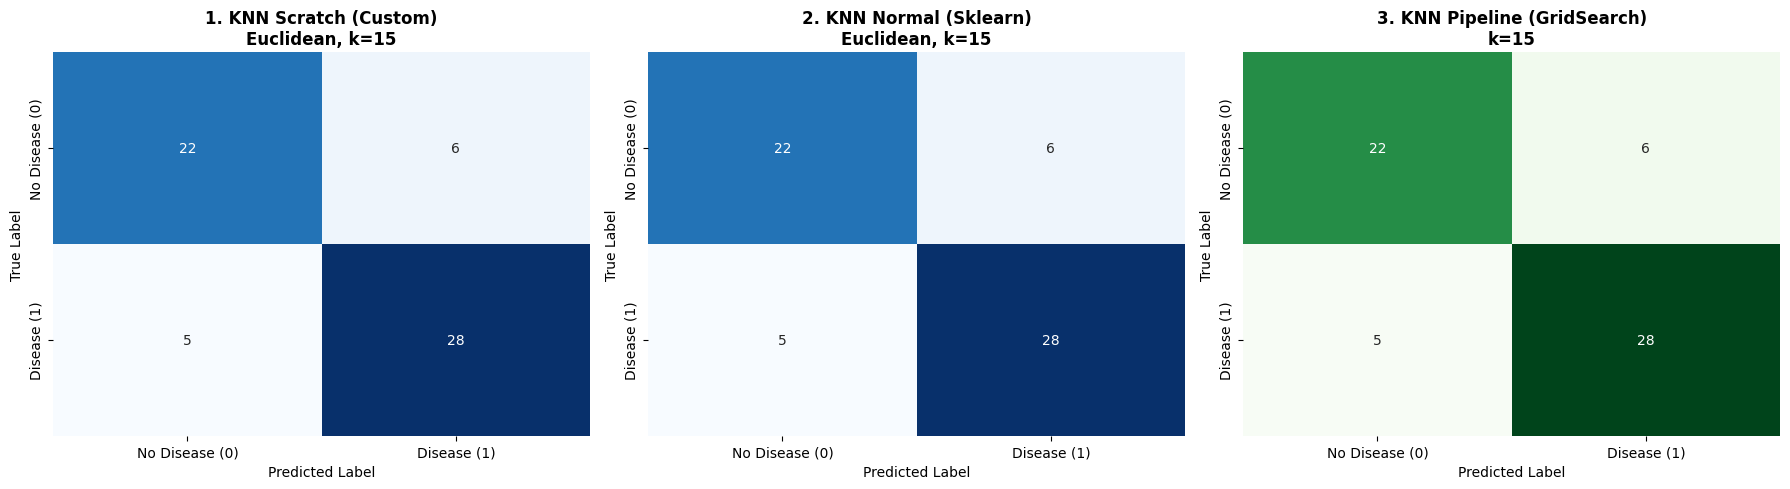

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: KNN Scratch
cm_scratch = confusion_matrix(y_test, y_pred_scratch)
sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f'1. KNN Scratch (Custom)\nEuclidean, k={best_k}', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'])
axes[0].set_yticklabels(['No Disease (0)', 'Disease (1)'])

# Plot 2: KNN Normal
cm_normal = confusion_matrix(y_test, y_pred_normal)
sns.heatmap(cm_normal, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title(f'2. KNN Normal (Sklearn)\nEuclidean, k={best_k}', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_xticklabels(['No Disease (0)', 'Disease (1)'])
axes[1].set_yticklabels(['No Disease (0)', 'Disease (1)'])

# Plot 3: KNN Pipeline
cm_pipe = confusion_matrix(y_test, y_pred_pipeline)
sns.heatmap(cm_pipe, annot=True, fmt='d', cmap='Greens', ax=axes[2], cbar=False)
axes[2].set_title(f'3. KNN Pipeline (GridSearch)\nk={best_k}', fontweight='bold')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')
axes[2].set_xticklabels(['No Disease (0)', 'Disease (1)'])
axes[2].set_yticklabels(['No Disease (0)', 'Disease (1)'])

plt.tight_layout()
plt.show()